1. Carga de librerias

In [ ]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.5 MB/s eta 0:00:00


In [ ]:
import gc
import os
import re
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim
import gensim.downloader as api
import joblib
import seaborn as sns
import shutil
import time
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import GridSearchCV
from gensim.models import Word2Vec
from gensim.test.utils import datapath
from gensim.models.word2vec import LineSentence
from gensim.models.callbacks import CallbackAny2Vec
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from google.colab import drive

# LOGGIN PARA VER PROGRESO EN WORD2VEC
import logging; logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)
print(f"Versión de Gensim: {gensim.__version__}")

# CLASIFICADORES
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

Versión de Gensim: 4.4.0


In [ ]:
!nproc

8


2. Carga, evaluación y preparación de datos

In [ ]:
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/Kaggle_DNA/Data/'
path = '/content/drive/MyDrive/Kaggle_DNA/Modelos/'

TRAIN_DATA = os.path.join(BASE_PATH, 'train.csv')
EVAL_DATA = os.path.join(BASE_PATH, 'eval.csv')

# Nombres de archivos para guardar embeddings
EMBEDDINGS_25 = 'dna_emb_25'
EMBEDDINGS_50 = 'dna_emb_50'
EMBEDDINGS_75 = 'dna_emb_75'
EMBEDDINGS_100 = 'dna_emb_100'
EMBEDDINGS_200 = 'dna_emb_200'
EMBEDDINGS_300 = 'dna_emb_300'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_train = pd.read_csv(TRAIN_DATA)
df_eval = pd.read_csv(EVAL_DATA)
col_adn = 'sequence'
col_label = 'is_mutated'

In [ ]:
# FUNCION PARA LIMPIEZA
def clean_and_prepare(df):
    cols_to_drop = [col_adn]
    if col_label in df.columns:
        cols_to_drop.append(col_label)

    df = df.dropna(subset=cols_to_drop)
    df = df.drop_duplicates(subset=[col_adn])
    df[col_adn] = df[col_adn].str.upper()
    return df

df_train = clean_and_prepare(df_train)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    df_train[col_adn].values,
    df_train[col_label].values,
    test_size=0.20,
    stratify=df_train[col_label].values,
    random_state=42
)

3. Construcción de modelo de clasificación

In [ ]:
# GENERACIÓN DE CORPUS MULTIESCALA
k_a_probar = [3, 4, 5]

for k in k_a_probar:
    fname = f"dna_corpus_k{k}.txt"
    print(f"Generando corpus para k={k}...")
    with open(fname, "w") as f:
        for seq in X_train:
            kmers = [seq[i:i+k] for i in range(len(seq) - k + 1)]
            f.write(" ".join(kmers) + "\n")
    print(f"Archivo listo: {fname}")

In [ ]:
# GENERACION DE CORPUS PARA K6

def generate_dna_corpus(sequences, k, output_path):
    print(f"Generando corpus para k={k}...")

    with open(output_path, 'w') as f:
        for i, seq in enumerate(sequences):
            # Generar hexámeros (paso 1)
            kmers = [seq[j:j+k] for j in range(len(seq) - (k - 1))]
            line = " ".join(kmers)
            f.write(line + "\n")
            if (i + 1) % 5000 == 0:
                print(f"✅ Procesadas {i + 1} secuencias...")

    print(f"Corpus guardado en: {output_path}")

# EJECUCIÓN
# path_corpus = os.path.join(path, 'Corpus')
file_name_k6 = os.path.join(path, 'corpus_k6.txt') # todos los archivos en la misma carpeta

generate_dna_corpus(X_train, k=6, output_path=file_name_k6)

Generando corpus para k=6...
✅ Procesadas 5000 secuencias...
✅ Procesadas 10000 secuencias...
✅ Procesadas 15000 secuencias...
✅ Procesadas 20000 secuencias...
✅ Procesadas 25000 secuencias...
✅ Procesadas 30000 secuencias...
✅ Procesadas 35000 secuencias...
Corpus guardado en: /content/drive/MyDrive/Kaggle_DNA/Modelos/corpus_k6.txt


In [ ]:
# RUTINA PARA SUBIR ARCHIVOS AL CONTENT PARA EJECUCION MAS RAPIDA

print("Copiando k4...")
shutil.copy('/content/drive/MyDrive/Kaggle_DNA/Modelos/dna_corpus_k4.txt', '/content/dna_corpus_k4.txt')

print("Copiando k5...")
shutil.copy('/content/drive/MyDrive/Kaggle_DNA/Modelos/dna_corpus_k5.txt', '/content/dna_corpus_k5.txt')

print("Copiando k6...")
shutil.copy('/content/drive/MyDrive/Kaggle_DNA/Modelos/corpus_k6.txt', '/content/corpus_k6.txt')

print("Archivos listos en el disco local.")

Copiando k4...
Copiando k5...
Copiando k6...
Archivos listos en el disco local.


In [ ]:
# CLASE PARA GUARDAR EPOCAS
class EpochSaver(CallbackAny2Vec):
    def __init__(self, path_prefix):
        self.path_prefix = path_prefix
        self.epoch = 1
    def on_epoch_end(self, model):
        output_path = f"{self.path_prefix}_epoch_{self.epoch}.model"
        model.save(output_path)
        print(f"Época {self.epoch} completada y guardada en Drive.")
        self.epoch += 1

In [ ]:
# CONSTRUCCION VECTOR K=5 - 100 dimensiones - 5 epocas
print("Iniciando protocolo K5...")

# Liberación de memoria
try:
    del model
except NameError:
    pass
gc.collect()

# Configuración de K5
k_5 = 5
d_5 = 100

checkpoint_folder = '/content/drive/MyDrive/Kaggle_DNA/Modelos/checkpoints_k5_V12/'
os.makedirs(checkpoint_folder, exist_ok=True)
checkpoint_prefix = os.path.join(checkpoint_folder, 'dna_k5_v12')

final_k5_path = '/content/drive/MyDrive/Kaggle_DNA/Modelos/dna_sg_k5_d100_5ep_V12.model'
ruta_corpus = "/content/dna_corpus_k5.txt"

print(f"Lanzando K5 V12 (dim={d_5}, window=10, min_count=2)...")
inicio = time.time()

model_k5 = gensim.models.Word2Vec(
    sentences=LineSentence(ruta_corpus),
    vector_size=d_5,
    window=10,
    min_count=2,
    workers=8,
    sg=1,
    hs=0,
    negative=10,
    ns_exponent=0.75,
    alpha=0.025,
    epochs=5,
    callbacks=[EpochSaver(checkpoint_prefix)]
)

# Guardado final del K5
model_k5.save(final_k5_path)

fin = time.time()
print(f"Modelo K5 V12 guardado exitosamente.")
print(f"Tiempo total: {(fin - inicio)/60:.2f} minutos.")

Iniciando protocolo K5...
Lanzando K5 V12 (dim=100, window=10, min_count=2)...
Época 1 completada y guardada en Drive.
Época 2 completada y guardada en Drive.
Época 3 completada y guardada en Drive.
Época 4 completada y guardada en Drive.
Época 5 completada y guardada en Drive.
Modelo K5 V12 guardado exitosamente.
Tiempo total: 118.77 minutos.


In [ ]:
# CONSTRUCCION VECTOR K=6 - 100 dimensiones - 5 epocas
print("Iniciando protocolo K6...")

# Liberación de memoria
try:
    del model # Borramos el modelo K5 de la RAM
except NameError:
    pass
gc.collect()

# CONFIGURACIÓN K6
k_6 = 6
d_6 = 100

checkpoint_folder = '/content/drive/MyDrive/Kaggle_DNA/Modelos/checkpoints_k6_V12/'
os.makedirs(checkpoint_folder, exist_ok=True)
checkpoint_prefix = os.path.join(checkpoint_folder, 'dna_k6_v12')

final_k6_path = '/content/drive/MyDrive/Kaggle_DNA/Modelos/dna_sg_k6_d100_5ep_V12.model'
ruta_corpus = "/content/corpus_k6.txt"

print(f"Lanzando K6 V12 (dim={d_6}, window=10, min_count=2)...")
inicio = time.time()

model_k6 = gensim.models.Word2Vec(
    sentences=LineSentence(ruta_corpus),
    vector_size=d_6,
    window=10,
    min_count=2,
    workers=8,
    sg=1,
    hs=0,
    negative=10,
    ns_exponent=0.75,
    alpha=0.025,
    epochs=5,
    callbacks=[EpochSaver(checkpoint_prefix)]
)

# Guardado final del K6
model_k6.save(final_k6_path)

fin = time.time()
print(f"Modelo K6 V12 guardado exitosamente.")
print(f"Tiempo total: {(fin - inicio)/60:.2f} minutos.")

Iniciando protocolo K6...
Lanzando K6 V12 (dim=100, window=10, min_count=2)...
Época 1 completada y guardada en Drive.
Época 2 completada y guardada en Drive.
Época 3 completada y guardada en Drive.
Época 4 completada y guardada en Drive.
Época 5 completada y guardada en Drive.
Modelo K6 V12 guardado exitosamente.
Tiempo total: 115.79 minutos.


In [ ]:
# CONSTRUCCION VECTOR K=4 - 100 dimensiones - 5 epocas
print("Iniciando protocolo K4...")

# Liberación de memoria
try:
    del model
except NameError:
    pass
gc.collect()

# Configuración de K4
k_4 = 4
d_4 = 100

checkpoint_folder = '/content/drive/MyDrive/Kaggle_DNA/Modelos/checkpoints_k4_V12/'
os.makedirs(checkpoint_folder, exist_ok=True)
checkpoint_prefix = os.path.join(checkpoint_folder, 'dna_k4_v12')

final_k4_path = '/content/drive/MyDrive/Kaggle_DNA/Modelos/dna_sg_k4_d100_5ep_V12.model'
ruta_corpus = "/content/dna_corpus_k4.txt"

print(f"Lanzando K4 V12 (dim={d_4}, window=10, min_count=2)...")
inicio = time.time()

model_k4 = gensim.models.Word2Vec(
    sentences=LineSentence(ruta_corpus),
    vector_size=d_4,
    window=10,
    min_count=2,
    workers=8,
    sg=1,
    hs=0,
    negative=10,
    ns_exponent=0.75,
    alpha=0.025,
    epochs=5,
    callbacks=[EpochSaver(checkpoint_prefix)]
)

# Guardado final del K4
model_k4.save(final_k4_path)

fin = time.time()
print(f"Modelo K4 V12 guardado exitosamente.")
print(f"Tiempo total: {(fin - inicio)/60:.2f} minutos.")

Iniciando protocolo K4...
Lanzando K4 V12 (dim=100, window=10, min_count=2)...
Época 1 completada y guardada en Drive.
Época 2 completada y guardada en Drive.
Época 3 completada y guardada en Drive.
Época 4 completada y guardada en Drive.
Época 5 completada y guardada en Drive.
Modelo K4 V12 guardado exitosamente.
Tiempo total: 94.44 minutos.


In [ ]:
# PREPROCESAMIENTO - CREACION DE EMBEDDINGS

class DNA_MultiScale_TriMetric_Preprocessing:
    def __init__(self, model_paths):
        self.models = []
        total_dim = 0
        for path in model_paths:
            model = gensim.models.Word2Vec.load(path)
            wv = model.wv
            # Detectamos el K automáticamente por el primer k-mer en el vocabulario
            k = len(wv.index_to_key[0])
            self.models.append({'wv': wv, 'k': k, 'size': wv.vector_size})
            # Se multiplica x 3 porque ahora concatenamos Mean, Max y STD
            total_dim += (wv.vector_size * 3)
            print(f"Escala k={k} cargada. Aportará {wv.vector_size * 3}d")
        print(f"Vector final listo. Dimensión total: {total_dim}")

    def transform(self, X):
        all_scales_embeddings = []
        for sequence in X:
            sequence_vectors = []
            for m in self.models:
                # Generar k-mers según la escala k del modelo actual
                kmers = [sequence[i:i+m['k']] for i in range(len(sequence) - (m['k'] - 1))]
                vectors = [m['wv'][t] for t in kmers if t in m['wv'].key_to_index]

                if not vectors:
                    # Si no hay vectores, llenamos con ceros (Triple métrica)
                    scale_rep = np.zeros(m['size'] * 3, dtype=np.float32)
                else:
                    vectors_array = np.asarray(vectors, dtype=np.float32)
                    # CÁLCULO DE LAS 3 MÉTRICAS
                    mean_v = np.mean(vectors_array, axis=0) # Tendencia central
                    max_v = np.max(vectors_array, axis=0)   # Señales prominentes
                    std_v = np.std(vectors_array, axis=0)   # Variabilidad estructural

                    # CONCATENACIÓN CRÍTICA (Orden: Mean, Max, Std)
                    scale_rep = np.concatenate([mean_v, max_v, std_v])

                sequence_vectors.append(scale_rep)

            # Unimos las 3 escalas (k4, k5, k6) en un solo vector de 900d
            all_scales_embeddings.append(np.concatenate(sequence_vectors))

        return np.array(all_scales_embeddings, dtype=np.float32)

In [ ]:
# GENERACION DE EMBEDDINGS Y CONCATENACION DE LOS RESULTADOS EN UNA UNICA MATRIZ (K4+K5+K6)
rutas_finales = [
    "/content/drive/MyDrive/Kaggle_DNA/Modelos/checkpoints_k4_V12/dna_k4_v12_epoch_3.model",
    "/content/drive/MyDrive/Kaggle_DNA/Modelos/checkpoints_k5_V12/dna_k5_v12_epoch_3.model", #3 epocas
    "/content/drive/MyDrive/Kaggle_DNA/Modelos/checkpoints_k6_V12/dna_k6_v12_epoch_3.model"
]

# CARGA Y TRANSFORMACIÓN
# TOTAL DIMENSIONES: K4 = 100, K5 = 100 Y K6 = 100, CADA MATRIZ SE TRIPLICA X RESULTADOS DE PROMEDIO, MAXIMO Y STD = 900 DIMENSIONES
print("Inicializando Preprocesador Multiescala (900 dimensiones)...")
preprocesador_900 = DNA_MultiScale_TriMetric_Preprocessing(rutas_finales)

print("Transformando X_train y X_val...")
X_train_900 = preprocesador_900.transform(X_train)
X_val_900 = preprocesador_900.transform(X_val)

#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#X_train_900 = scaler.fit_transform(X_train_900)
#X_val_900 = scaler.transform(X_val_900)

print(f"Estructura final: {X_train_900.shape}") # Debería ser (37336, 900)


Inicializando Preprocesador Multiescala (900 dimensiones)...
Escala k=4 cargada. Aportará 300d
Escala k=5 cargada. Aportará 300d
Escala k=6 cargada. Aportará 300d
Vector final listo. Dimensión total: 900
Transformando X_train y X_val...
Estructura final: (37336, 900)


In [ ]:
# GUARDAR MATRIZ

# Definir la ruta en tu Drive
ruta_matriz = "/content/drive/MyDrive/Kaggle_DNA/Matrices/matriz_900d_v12.pkl"

# Crear carpeta si no existe
os.makedirs(os.path.dirname(ruta_matriz), exist_ok=True)

# Guardamos un diccionario con todo lo necesario
data_to_save = {
    'X_train': X_train_900,
    'X_val': X_val_900,
    'y_train': y_train,
    'y_val': y_val
}

joblib.dump(data_to_save, ruta_matriz)
print(f"Matriz guardada exitosamente en: {ruta_matriz}")

Matriz guardada exitosamente en: /content/drive/MyDrive/Kaggle_DNA/Matrices/matriz_900d_v12.pkl


In [ ]:
# RECUPERAR MATRIZ

# Definir la ruta donde guardaste el archivo
ruta_matriz = "/content/drive/MyDrive/Kaggle_DNA/Matrices/matriz_900d_v12.pkl"

print(f"Cargando matriz desde {ruta_matriz}...")

# Cargar el diccionario
data_loaded = joblib.load(ruta_matriz)

# Extraer las variables de vuelta al entorno
X_train_900 = data_loaded['X_train']
X_val_900 = data_loaded['X_val']
y_train = data_loaded['y_train']
y_val = data_loaded['y_val']

print("Datos recuperados con éxito.")
print(f"Dimensiones de entrenamiento: {X_train_900.shape}")
print(f"Dimensiones de validación:    {X_val_900.shape}")

# Re-escalar para Regresión Logística
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_900)
X_val_scaled = scaler.transform(X_val_900)
print("Matrices escaladas y listas para modelos lineales.")

Cargando matriz desde /content/drive/MyDrive/Kaggle_DNA/Matrices/matriz_900d_v12.pkl...
Datos recuperados con éxito.
Dimensiones de entrenamiento: (37336, 900)
Dimensiones de validación:    (9335, 900)
Matrices escaladas y listas para modelos lineales.


In [ ]:
# REVISION CLASIFICADORES

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_900)
X_val_scaled = scaler.transform(X_val_900)
print("Matrices escaladas y listas para modelos lineales.")

# Definición extendida de los 8 modelos
configs = [
    ('RL_Fuerte', LogisticRegression(C=0.01, solver='saga', max_iter=2000, n_jobs=-1)),
    ('RL_Media', LogisticRegression(C=0.1, solver='saga', max_iter=2000, n_jobs=-1)),
    ('RL_Suave', LogisticRegression(C=1.0, solver='saga', max_iter=2000, n_jobs=-1)),

    # XGBoost
    ('XGB_Moderado', XGBClassifier(max_depth=3, colsample_bytree=0.4, n_estimators=300, learning_rate=0.02, tree_method='hist')),
    ('XGB_Estructural', XGBClassifier(max_depth=4, reg_lambda=10, n_estimators=300, learning_rate=0.02, tree_method='hist')),

    # LightGBM
    ('LGBM_Dardos', LGBMClassifier(max_depth=3, num_leaves=7, n_estimators=500, learning_rate=0.03, importance_type='gain', n_jobs=-1, verbose=-1)),

    # LGBM_Bosque: Más capacidad, con regularización fuerte (path_smooth)
    ('LGBM_Bosque', LGBMClassifier(max_depth=5, num_leaves=31, n_estimators=500, learning_rate=0.03, reg_lambda=5, n_jobs=-1, verbose=-1))
]

best_f1_v = 0
ganador_nombre = ""
ganador_modelo = None

print(f"{'Modelo':<18} | {'F1-Train':<10} | {'F1-Val':<10} | {'Gap':<10}")
print("-" * 60)

for nombre, model in configs:

    if 'RL' in nombre:
        model.fit(X_train_scaled, y_train)
        train_pred = model.predict(X_train_scaled)
        val_pred = model.predict(X_val_scaled)
    else:
        model.fit(X_train_900, y_train)
        train_pred = model.predict(X_train_900)
        val_pred = model.predict(X_val_900)

    f1_t = f1_score(y_train, train_pred, average='macro')
    f1_v = f1_score(y_val, val_pred, average='macro')
    gap = f1_t - f1_v

    print(f"{nombre:<18} | {f1_t:.4f} | {f1_v:.4f} | {gap:.4f}")

    if f1_v > best_f1_v:
        best_f1_v = f1_v
        ganador_nombre = nombre
        ganador_modelo = model

print("-" * 60)
print(f"EL MODELO GANADOR ES: {ganador_nombre}")
print(f"F1-Val Record: {best_f1_v:.4f}")

# Guardar el ganador automáticamente para no perderlo
import joblib
ruta_ganador = f"/content/drive/MyDrive/Kaggle_DNA/Modelos/GANADOR_{ganador_nombre}.pkl"
joblib.dump(ganador_modelo, ruta_ganador)
print(f"Modelo guardado en: {ruta_ganador}")


Matrices escaladas y listas para modelos lineales.
Modelo             | F1-Train   | F1-Val     | Gap       
------------------------------------------------------------
RL_Fuerte          | 0.6789 | 0.6717 | 0.0071
RL_Media           | 0.6786 | 0.6719 | 0.0067
RL_Suave           | 0.6788 | 0.6716 | 0.0071
XGB_Moderado       | 0.6793 | 0.6532 | 0.0261
XGB_Estructural    | 0.7009 | 0.6710 | 0.0299
LGBM_Dardos        | 0.7139 | 0.6807 | 0.0331
LGBM_Bosque        | 0.7888 | 0.6961 | 0.0927
------------------------------------------------------------
EL MODELO GANADOR ES: LGBM_Bosque
F1-Val Record: 0.6961
Modelo guardado en: /content/drive/MyDrive/Kaggle_DNA/Modelos/GANADOR_LGBM_Bosque.pkl


Evaluando con Matrices Originales (Usado por LGBM_Bosque)

REPORTE DE CLASIFICACIÓN - LGBM_Bosque
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.65      0.68      4665
           1       0.68      0.74      0.71      4670

    accuracy                           0.70      9335
   macro avg       0.70      0.70      0.70      9335
weighted avg       0.70      0.70      0.70      9335



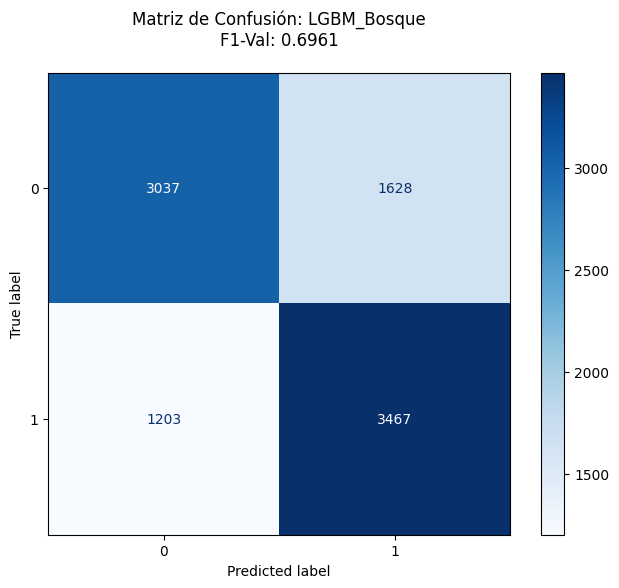

In [ ]:
# MATRIZ DE CONFUSION

# Determinar qué matriz de validación usar según el ganador
if 'RL' in ganador_nombre:
    X_eval = X_val_scaled
    print(f"Evaluando con Matrices Escaladas (Requerido por {ganador_nombre})")
else:
    X_eval = X_val_900
    print(f"Evaluando con Matrices Originales (Usado por {ganador_nombre})")

# Realizar predicciones con el objeto 'ganador_modelo'
y_pred_ganador = ganador_modelo.predict(X_eval)

# Generar el reporte de texto (Ajuste menor para evitar warnings)
print(f"\nREPORTE DE CLASIFICACIÓN - {ganador_nombre}")
print("-" * 55)
# zero_division=0 evita errores si una clase no tiene predicciones
print(classification_report(y_val, y_pred_ganador, zero_division=0))

cm = confusion_matrix(y_val, y_pred_ganador)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases_dna)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d') # values_format='d' para números enteros
plt.title(f'Matriz de Confusión: {ganador_nombre}\nF1-Val: {best_f1_v:.4f}', pad=20)
plt.grid(False)
plt.show()

In [ ]:
# LGBM OPTIMIZADO
nombre1 = 'LGBM Optimizado'
model1 =LGBMClassifier(
    n_estimators=800,
    learning_rate=0.02,

    max_depth=6,
    num_leaves=25,

    feature_fraction=0.75,
    bagging_fraction=0.8,
    bagging_freq=5,

    min_child_samples=40,

    reg_lambda=8,
    reg_alpha=1,

    importance_type='gain',
    n_jobs=-1,
    verbose=-1
)

In [ ]:
model1.fit(X_train_900, y_train)
train_pred = model1.predict(X_train_900)
val_pred = model1.predict(X_val_900)
print(f"{'Modelo':<18} | {'F1-Train':<10} | {'F1-Val':<10} | {'Gap':<10}")
print("-" * 60)
f1_t1 = f1_score(y_train, train_pred, average='macro')
f1_v1 = f1_score(y_val, val_pred, average='macro')
gap1 = f1_t1 - f1_v1

print(f"{nombre1:<18} | {f1_t1:.4f} | {f1_v1:.4f} | {gap1:.4f}")


Modelo             | F1-Train   | F1-Val     | Gap       
------------------------------------------------------------
LGBM Optimizado    | 0.8032 | 0.7070 | 0.0962


In [ ]:
# LR + LGBM STACK
w1 = 0.3
w2 = 0.7

model2 = LogisticRegression(C=0.1, max_iter=2000, n_jobs=-1)
model2.fit(X_train_scaled, y_train)

# Probabilidades TRAIN
proba_lr_train = model2.predict_proba(X_train_scaled)
proba_lgbm_train = model1.predict_proba(X_train_900)

proba_train_final = proba_lr_train*w1 + proba_lgbm_train*w2
train_pred_stack = np.argmax(proba_train_final, axis=1)

# Probabilidades VAL
proba_lr = model2.predict_proba(X_val_scaled)
proba_lgbm = model1.predict_proba(X_val_900)

proba_final = proba_lr * w1 + proba_lgbm * w2
y_pred_stack = np.argmax(proba_final, axis=1)

# Métricas
f1_t2 = f1_score(y_train, train_pred_stack, average='macro')
f1_v2 = f1_score(y_val, y_pred_stack, average='macro')
gap2 = f1_t2 - f1_v2

print(f"{'Modelo':<18} | {'F1-Train':<10} | {'F1-Val':<10} | {'Gap':<10}")
print("-" * 60)
print(f"{'Stack LR+LGBM':<18} | {f1_t2:.4f} | {f1_v2:.4f} | {gap2:.4f}")


Modelo             | F1-Train   | F1-Val     | Gap       
------------------------------------------------------------
Stack LR+LGBM      | 0.7862 | 0.7153 | 0.0709


MODELO XGBOOST

In [ ]:
# ENTRENAMIENTO DEL CLASIFICADOR "SUBMISSION READY"
print("Entrenando XGBoost de alta resolución...")
clf_900 = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,       # Bajamos un poco para mayor estabilidad
    max_depth=6,              # Un poco más conservador
    subsample=0.8,
    colsample_bytree=0.5,     # Clave para manejar las 360d
    n_jobs=-1,
    random_state=42,
    tree_method='hist',
    eval_metric='logloss'
)
print("Iniciando entrenamiento")
clf_900.fit(X_train_900, y_train)

# EVALUACIÓN DE ORO
y_pred_900 = clf_900.predict(X_val_900)
f1_900 = f1_score(y_val, y_pred_900, average='macro')

print(f"\n RESULTADO CON 360 DIMENSIONES ")
print(f"F1-Score (Macro): {f1_900:.4f}")
print("-" * 30)
print(classification_report(y_val, y_pred_900))

In [ ]:
# MATRIZ DE CONFUSIÓN
print("\n Generando Matriz de Confusión...")

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_900,
    display_labels=['Normal', 'Mutada'],
    cmap='Blues',
    values_format='d',
    ax=ax
)
plt.title(f'Matriz de Confusión Final (900d)\nF1-Score Macro: {f1_900:.4f}', fontsize=14)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# GRÁFICO DE IMPORTANCIA DE DIMENSIONES (Feature Importance)
importancias = clf_900.feature_importances_

# Definimos los límites de cada escala
# k4: 0-59 (60d), k5: 61-259 (200d), k6: 260-459 (200d)
plt.figure(figsize=(18, 6))

# Colores para identificar las escalas
colores = ['#4A90E2']*60 + ['#50E3C2']*200 + ['#FFD700']*200
indices = np.arange(len(importancias))

plt.bar(indices, importancias, color=colores, alpha=0.8, edgecolor='none')

# Líneas divisorias para separar k4, k5 y k6
plt.axvline(x=59.5, color='red', linestyle='--', alpha=0.6)
plt.axvline(x=259.5, color='red', linestyle='--', alpha=0.6)

plt.title('Importancia de Dimensiones (mean - max): k4 (Azul) vs k5 (Verde) vs k6 (Oro)', fontsize=15)
plt.xlabel('Índice del Embedding', fontsize=12)
plt.ylabel('Importancia (Gini)', fontsize=12)

# Leyenda manual
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='#4A90E2', lw=4),
                Line2D([0], [0], color='#50E3C2', lw=4),
                Line2D([0], [0], color='#FFD700', lw=4)]
plt.legend(custom_lines, ['k=4 (30d)', 'k=5 (100d)', 'k=6 (100d)'])
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.show()

# Resumen de contribución por escala
print(f"📊 Contribución acumulada k=4 (60d): {np.sum(importancias[:60]):.4f}")
print(f"📊 Contribución acumulada k=5 (200d): {np.sum(importancias[60:260]):.4f}")
print(f"📊 Contribución acumulada k=6 (200d): {np.sum(importancias[260:]):.4f}")
print(f"🏆 Dimensión más influyente: {np.argmax(importancias)} con valor {np.max(importancias):.4f}")

4. Evaluación final y generación de submission

5. Otros codigos y/o rutinas

In [ ]:
# RUTINA PARA REFRESCAR DRIVE DE COLABS
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
# RUTINA PARA LIMPIAR MEMORIA RAM AMBIENTE COLABS
# Eliminamos modelos viejos de la RAM si quedaron cargados
if 'model' in locals(): del model
if 'preprocesador_900' in locals(): del preprocesador_900
gc.collect() # Forzamos la limpieza de basura en RAM

0

In [ ]:
if 'X_train_900' in locals(): del X_train_900
if 'X_val_900' in locals(): del X_val_900
gc.collect()

0